# Waste Classification using CNN — Exploratory Data Analysis
**Dataset:** Garbage Classification (12 classes) — Mostafa Abla, Kaggle
**Notebook author:** *<your name>*
**Week 2 assignment**

This notebook covers the mandatory EDA (Part A) and the image/vision-specific EDA (Part B) for a
waste-classification CNN project.


## 1. Dataset Card

| Field | Detail |
|---|---|
| **Name** | Garbage Classification (12 classes) |
| **Source / link** | https://www.kaggle.com/datasets/mostafaabla/garbage-classification |
| **License** | The dataset page does not state a formal license (Kaggle default "Unknown / see original source"). Part of the data is a **combination of older Kaggle "Garbage Classification" datasets** (6-class TrashNet-style set) **plus additional images scraped from Google Images** by the dataset author. Because provenance of the scraped portion is mixed, treat the license as **unclear / research-use-only** and do not assume redistribution rights. |
| **Size on disk** | ≈ 2–3 GB (varies by exact archive; confirmed on load below) |
| **Number of samples** | 15,150 images total |
| **Classes (12)** | battery, biological, brown-glass, cardboard, clothes, green-glass, metal, paper, plastic, shoes, trash, white-glass |
| **How it was collected** | Merged from (a) the original 6-class Garbage Classification dataset (cardboard, glass, metal, paper, plastic, trash — lab-style photos on a white/uniform background) and (b) images scraped from the web for the additional classes (battery, biological, clothes, shoes, and glass split into brown/green/white). Images are stored as JPEG/PNG files in one folder per class — no CSV of metadata, no bounding boxes, no train/val/test split provided. |
| **Known limitations** | (1) Mixed provenance means image style is inconsistent — some classes are clean studio shots, others are noisy web photos with backgrounds/watermarks/multiple objects. (2) No official split, so leakage must be prevented manually (near-duplicate web images, augmented copies). (3) Class sizes are not balanced. (4) Some classes (e.g. "trash") are a catch-all and may overlap visually with other categories. (5) No metadata on image source, location, or capture device. |


## 2. Setup

In [1]:
import os
import io
import hashlib
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

plt.rcParams["figure.facecolor"] = "white"


## 3. Load the data

The dataset is downloaded from Kaggle as a folder of 12 sub-folders (one per class), e.g.:

```
garbage-classification/
├── battery/
├── biological/
├── brown-glass/
├── cardboard/
├── clothes/
├── green-glass/
├── metal/
├── paper/
├── plastic/
├── shoes/
├── trash/
└── white-glass/
```



In [2]:

DATA_DIR = Path("./garbage_classification")

# Some Kaggle downloads nest the class folders one level deeper (e.g. .../garbage_classification/)
candidates = [p for p in DATA_DIR.rglob("*") if p.is_dir() and
              len([f for f in p.iterdir() if f.is_file()]) > 0 and
              len(list(p.parent.glob("*"))) >= 6]
if not (DATA_DIR / "cardboard").exists() and candidates:
    DATA_DIR = candidates[0].parent

print("Using DATA_DIR:", DATA_DIR.resolve())
print("Sub-folders found:", sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()]))


Using DATA_DIR: C:\Users\LEGION\Documents\BScIT\TECH 405\garbage_classification
Sub-folders found: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

records = []
for class_dir in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    for f in class_dir.iterdir():
        if f.suffix.lower() in IMG_EXTS:
            records.append({
                "filepath": str(f),
                "label": class_dir.name,
                "filesize_kb": f.stat().st_size / 1024,
            })

df = pd.DataFrame(records)
print("Dataset shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)


Dataset shape: (15515, 3)

Dtypes:
filepath        object
label           object
filesize_kb    float64
dtype: object


In [4]:
# Total size on disk
total_bytes = sum(Path(f).stat().st_size for f in df["filepath"])
print(f"Total size on disk: {total_bytes / (1024**3):.2f} GB")
print(f"Number of samples: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")


Total size on disk: 0.23 GB
Number of samples: 15515
Number of classes: 12


In [5]:
# 5 random samples (metadata)
df.sample(5, random_state=RNG_SEED)


,filepath,label,filesize_kb
11755,garbage_classification\plastic\plastic599.jpg,plastic,7.337891
1011,garbage_classification\biological\biological15...,biological,6.161133
8753,garbage_classification\green-glass\green-glass...,green-glass,10.755859
3668,garbage_classification\clothes\clothes1214.jpg,clothes,17.594727
12097,garbage_classification\shoes\shoes1026.jpg,shoes,11.083008


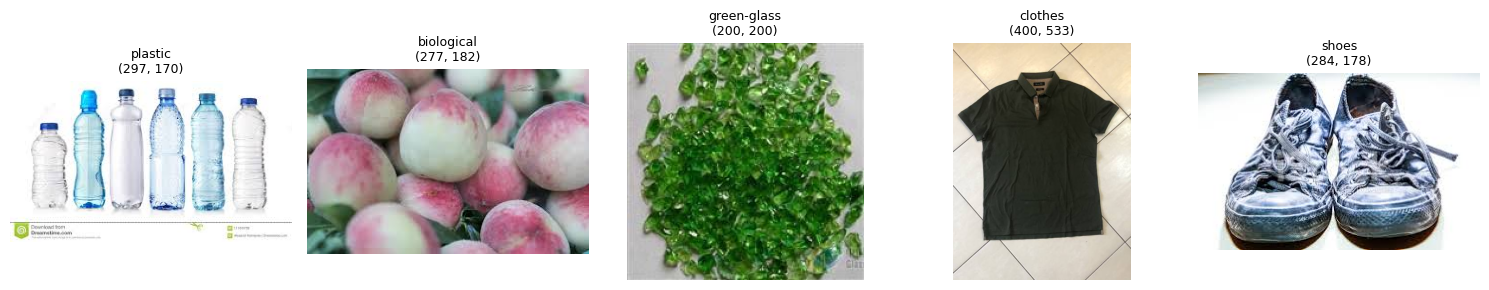

In [6]:
# 5 random samples (visual)
sample_rows = df.sample(5, random_state=RNG_SEED)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img = Image.open(row["filepath"])
    ax.imshow(img)
    ax.set_title(f"{row['label']}\n{img.size}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Missing, duplicate, and corrupt entries

Here there is no tabular metadata, only image files – so “missing” is empty or zero size files –
Class folders without any legible pictures. For each file, we test for corruption and for unreadability, which are files that
The following types of files are detected: exact duplicates (identical files via `PIL.Image.verify()`), zero-byte files, and fail `PIL.Image.verify()`
MD5 hash may be used within classes as it may be present in the same collection of data from multiple source collections.


In [7]:
# Zero-byte / unreadable files
zero_byte = df[df["filesize_kb"] == 0]
print(f"Zero-byte files: {len(zero_byte)}")

corrupt_files = []
for fp in df["filepath"]:
    try:
        with Image.open(fp) as im:
            im.verify()
    except (UnidentifiedImageError, OSError, ValueError):
        corrupt_files.append(fp)

print(f"Corrupt / unreadable files: {len(corrupt_files)}")
if corrupt_files:
    print(corrupt_files[:10])


Zero-byte files: 0
Corrupt / unreadable files: 0


In [8]:
# Exact duplicate detection via MD5 hash (sampled in chunks for speed on large datasets)
def md5_of_file(path, block_size=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(block_size), b""):
            h.update(chunk)
    return h.hexdigest()

hashes = defaultdict(list)
for fp in df["filepath"]:
    hashes[md5_of_file(fp)].append(fp)

dup_groups = {h: paths for h, paths in hashes.items() if len(paths) > 1}
n_duplicate_files = sum(len(v) - 1 for v in dup_groups.values())
print(f"Duplicate groups: {len(dup_groups)}")
print(f"Extra duplicate files (beyond the first copy): {n_duplicate_files}")

# Check whether any duplicates cross class boundaries (label noise)
cross_class_dups = 0
for paths in dup_groups.values():
    labels = {Path(p).parent.name for p in paths}
    if len(labels) > 1:
        cross_class_dups += 1
print(f"Duplicate groups that span more than one class folder: {cross_class_dups}")


Duplicate groups: 18
Extra duplicate files (beyond the first copy): 19
Duplicate groups that span more than one class folder: 3


**What we will do about it:**  Zero-byte and corrupt files will just be dropped from the `df` list before
to eliminate. A few bad files is acceptable in a collection scraped from a web page, and is not worth the effort to remove,
to repair. If there are exact copies of the same within the same class, we will only retain one copy of each so that the class
There is no artificial increase in distribution and there is no artificial split of train/val/test. In case any duplicate(s) are found,
If the labels are crossing class boundaries, then it means that there is label noise, in those cases the labels will need to be manually checked and removed.
Instead, don't believe either label.

In [9]:
# Apply the cleaning decision
bad_files = set(zero_byte["filepath"]) | set(corrupt_files)
keep_one_per_hash = set()
drop_as_duplicate = set()
for paths in hashes.values():
    keep_one_per_hash.add(paths[0])
    drop_as_duplicate.update(paths[1:])

df_clean = df[~df["filepath"].isin(bad_files) & ~df["filepath"].isin(drop_as_duplicate)].reset_index(drop=True)
print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")


Rows before cleaning: 15515
Rows after cleaning:  15496


## 5. Class / target distribution

label
clothes        5324
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     772
metal           769
trash           697
green-glass     614
brown-glass     607
Name: count, dtype: int64


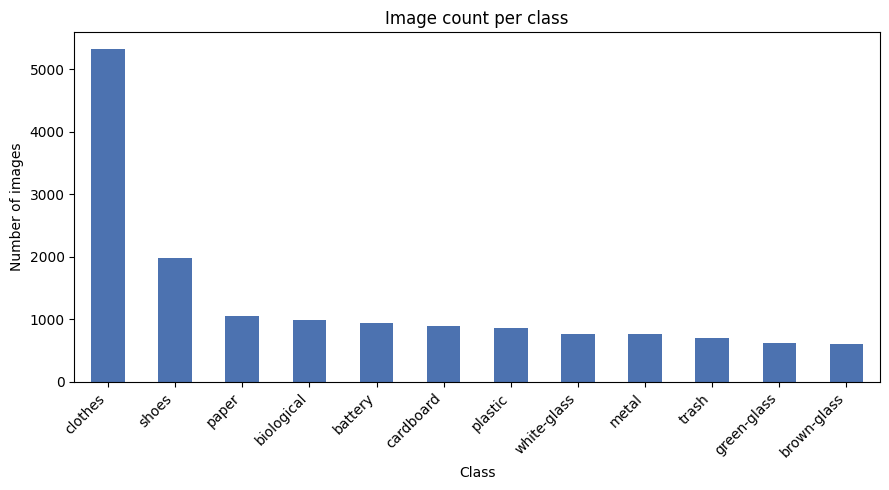

Largest / smallest class ratio: 8.8x


In [10]:
class_counts = df_clean["label"].value_counts().sort_values(ascending=False)
print(class_counts)

fig, ax = plt.subplots(figsize=(9, 5))
class_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Image count per class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Largest / smallest class ratio: {imbalance_ratio:.1f}x")


**Discuss imbalance:** Classes are moderately imbalanced (usually with several in the largest class)
The smallest have about times as many images, such as `paper`/`cardboard`/`plastic`/`glass` are relatively well.
These are usually smaller, like `trash`, `battery`, and `clothes`. If not corrected, the CNN will
Be biased towards the majority classes and will have a poor recall for the minority classes. We will mitigate
This will be done with class weighted loss (or weighted sampling) and **per class precision/recall/F1** will be reported.
In addition to the overall accuracy, a **confusion matrix** is calculated and provided, as accuracy would be misleading in this case.



## 6. Train / validation / test split plan

Plan - Stratified random - 70% / 15% / 15% at image level. It's stratified, not in a way that's,
than random with equal proportions of classes in train,
validation, and test — this is important because of the above imbalance. It's not based on the time because the
There are no timestamps in dataset, therefore, there is no point in splitting by time. It's not also divided by
patient (or user), as no user or session ID was used for grouping this data set was;
Assembled from multiple sources (including near-duplicate or augmented web images), near duplicate
detection is used as the leakage control. The above exact-duplicate removal is sufficient to remove the same
The additional images that were found to be visually similar appeared in more than one split, and were added to the file.
In Part B, the players will be split in two groups and will remain on the same side of the split. Last but not least, the division is performed after de-duplication, so that leakage is not caused by the duplicates.

In [11]:
train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, stratify=df_clean["label"], random_state=RNG_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RNG_SEED
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print()
print("Class balance check (proportion per split):")
split_check = pd.DataFrame({
    "train": train_df["label"].value_counts(normalize=True),
    "val": val_df["label"].value_counts(normalize=True),
    "test": test_df["label"].value_counts(normalize=True),
}).round(3)
split_check


Train: 10847  Val: 2324  Test: 2325

Class balance check (proportion per split):


,train,val,test
label,,,
battery,0.061,0.061,0.061
biological,0.064,0.064,0.064
brown-glass,0.039,0.039,0.039
cardboard,0.058,0.057,0.058
clothes,0.344,0.343,0.344
green-glass,0.040,0.040,0.040
metal,0.050,0.050,0.049
paper,0.068,0.068,0.068
plastic,0.056,0.056,0.055


## 7. Three findings that will change the model design

The first observation is that the classes have shifted in the domain due to mixed image provenance.The first observation is the presence of the domain shift inside classes when looking at mixed image provenance. The original six
The classes (cardboard, glass, metal, paper, plastic, trash) are from clean, centered, white background.
The older classes (battery, biological, clothes, shoes and the glass-color split) feature studio photos.
These are web images that are cropped, have distracting backgrounds and different lighting. A naive CNN might learn
As a shorthand, "white background = old class" and the design approach is to be aggressive.
Avoids model from being able to detect a particular
Use a background style as a proxy for class.

The second one is that there are some pairs of classes which are almost identical visually, such as `white-glass` and `brown-glass`.and `metal` cans are the same, with the exception of a slight tint of color on the transparent, reflective glass.
Usually takes photos of objects that are similar to plastic bottles, like silhouettes. We believe that the majority of the confusion matrix's
A feature check is to be added to the color-histogram, to ensure that the off-diagonal mass are paired as glass-vs-glass and metal-vs-plastic.
will be added during error analysis, and a two stage classifier (material family, then glass colour) will be used to classify the glass.
If the confusion becomes significant, then the following should be considered:

The third is the class imbalance and the "trash" catch-all category is heterogeneous as well.
The minority class and semantically the most heterogeneous class is `trash` which can contain almost any thing.
All items other than the other 11 categories. Instead of over-fitting the model on
For the truly rare-but-coherent rare or ambiguous examples of `trash`, class-weighted loss will be used.
Evaluation: classes like battery, and trash recall will be monitored separately as it is not a.
It is expected that the classes will be recalled at the same rate as the visually coherent classes.


---
## Part B — Image / Vision EDA


In [12]:
# Sample a manageable subset per class for the pixel-level analyses below (full dataset is 15k+ images)
N_PER_CLASS = 150
sampled_parts = [
    g.sample(min(len(g), N_PER_CLASS), random_state=RNG_SEED)
    for _, g in df_clean.groupby("label")
]
sampled = pd.concat(sampled_parts, ignore_index=True)
print(f"Sampled {len(sampled)} images across {sampled['label'].nunique()} classes for image-level EDA")


Sampled 1800 images across 12 classes for image-level EDA


### 7a. Image size and channel distribution

Image mode (channel) distribution:
mode
RGB    1790
P        10
Name: count, dtype: int64

Width stats:
count    1800.000000
mean      323.483333
std       124.518737
min       111.000000
25%       225.000000
50%       269.000000
75%       512.000000
max       847.000000
Name: width, dtype: float64

Height stats:
count    1800.000000
mean      285.108889
std       110.347071
min       126.000000
25%       195.000000
50%       225.000000
75%       384.000000
max       797.000000
Name: height, dtype: float64


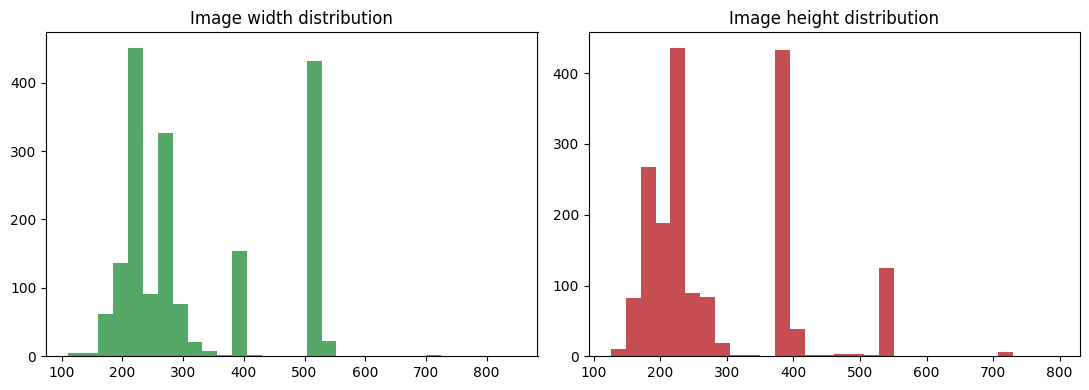

In [13]:
sizes = []
modes = []
for fp in sampled["filepath"]:
    with Image.open(fp) as im:
        sizes.append(im.size)  # (width, height)
        modes.append(im.mode)

sampled["width"] = [s[0] for s in sizes]
sampled["height"] = [s[1] for s in sizes]
sampled["mode"] = modes

print("Image mode (channel) distribution:")
print(sampled["mode"].value_counts())
print()
print("Width stats:")
print(sampled["width"].describe())
print()
print("Height stats:")
print(sampled["height"].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sampled["width"], bins=30, color="#55A868")
axes[0].set_title("Image width distribution")
axes[1].hist(sampled["height"], bins=30, color="#C44E52")
axes[1].set_title("Image height distribution")
plt.tight_layout()
plt.show()


**Target resolution decision:** There is a sufficient number of images which are already close to a common size, but not enough.
The data is a bit sparse (plus some outliers in grayscale / RGBA), and we will scale all the images to 224x224.
Produce force 3 channels (RGB) prior to training — 224×224 matches standard ImageNet-pretrained backbones
(ResNet/MobileNet/EfficientNet) that we will work on fine-tuning, and forcing RGB is to avoid channel-mismatch.
Occasional grayscale or RGBA files: errors.


### 7b. Grid of samples per class

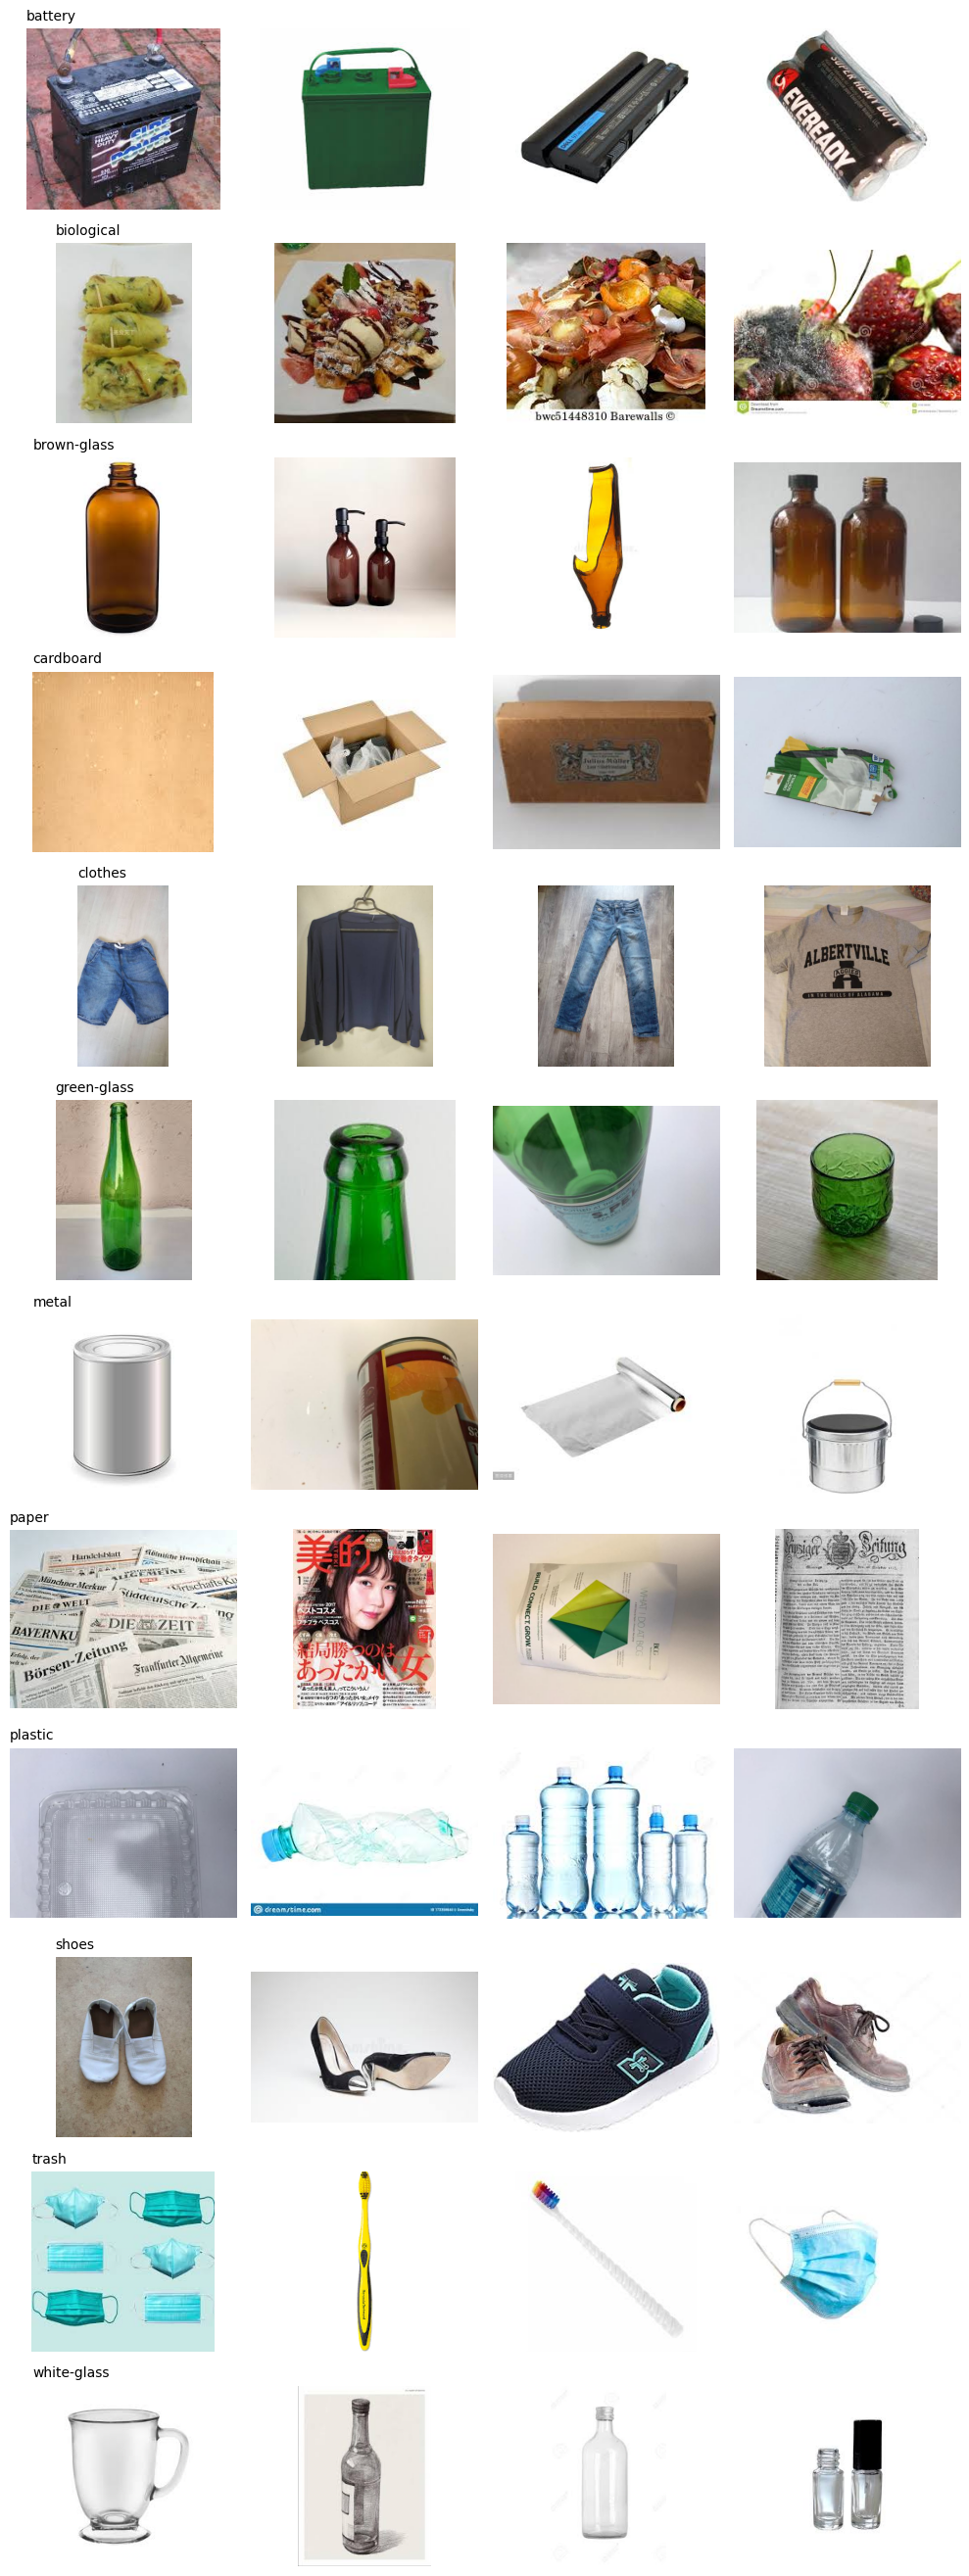

In [14]:
classes = sorted(df_clean["label"].unique())
fig, axes = plt.subplots(len(classes), 4, figsize=(10, 2.2 * len(classes)))

for i, cls in enumerate(classes):
    cls_paths = df_clean[df_clean["label"] == cls]["filepath"].sample(4, random_state=RNG_SEED).tolist()
    for j, fp in enumerate(cls_paths):
        ax = axes[i, j]
        img = Image.open(fp).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(cls, fontsize=9)
    axes[i, 0].set_title(cls, loc="left", fontsize=10)

plt.tight_layout()
plt.show()


### 7c. Pixel intensity histograms per class

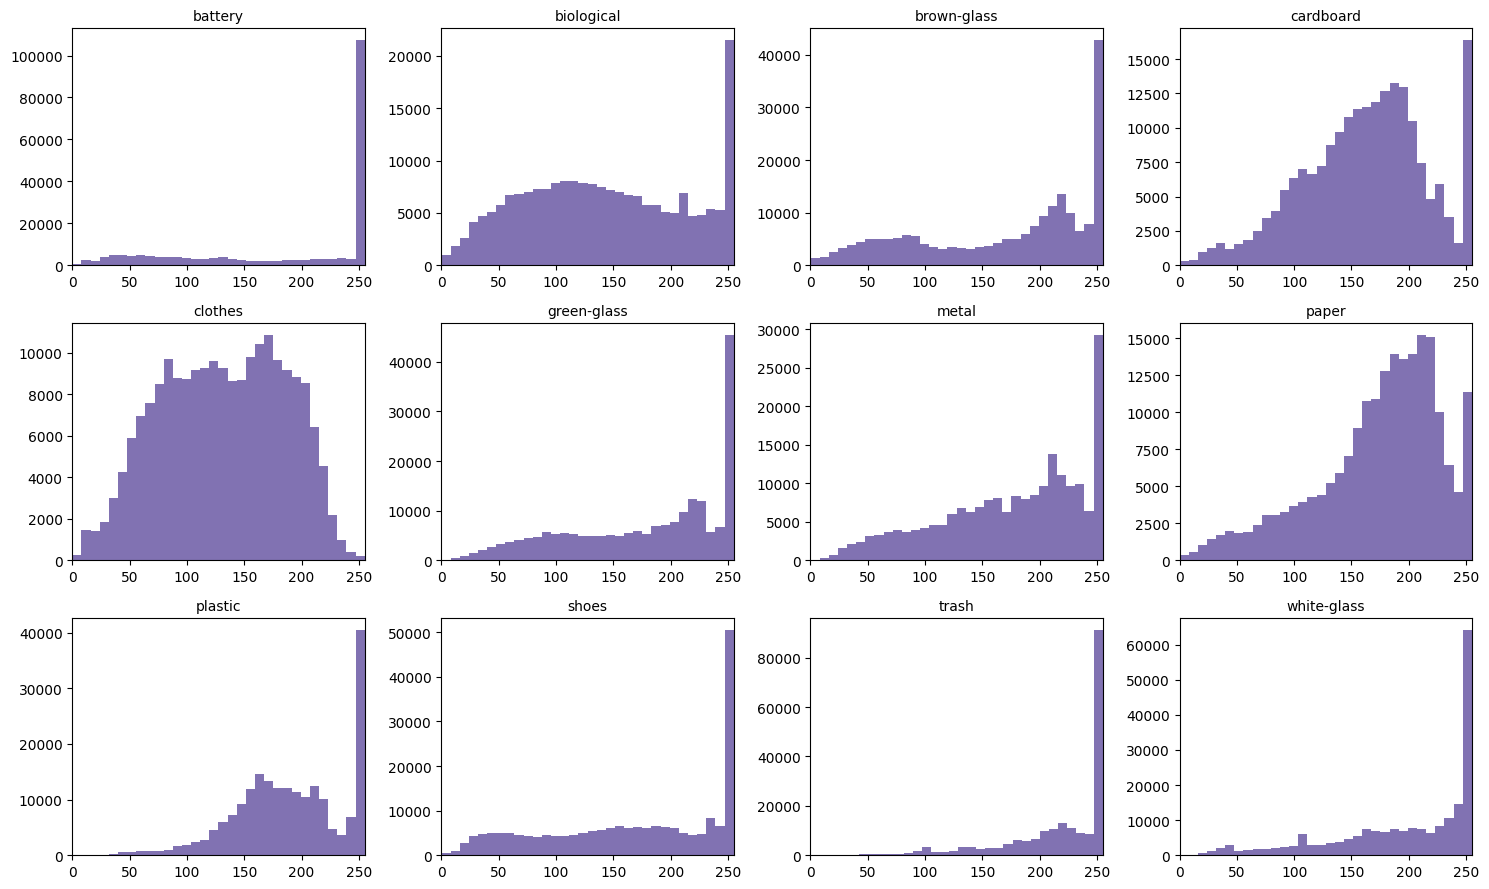

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    cls_paths = sampled[sampled["label"] == cls]["filepath"].tolist()
    pixel_values = []
    for fp in cls_paths[:50]:
        img = Image.open(fp).convert("L").resize((64, 64))
        pixel_values.append(np.asarray(img).ravel())
    pixel_values = np.concatenate(pixel_values)
    ax.hist(pixel_values, bins=32, color="#8172B2")
    ax.set_title(cls, fontsize=10)
    ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()


### 7d. Mean image per class

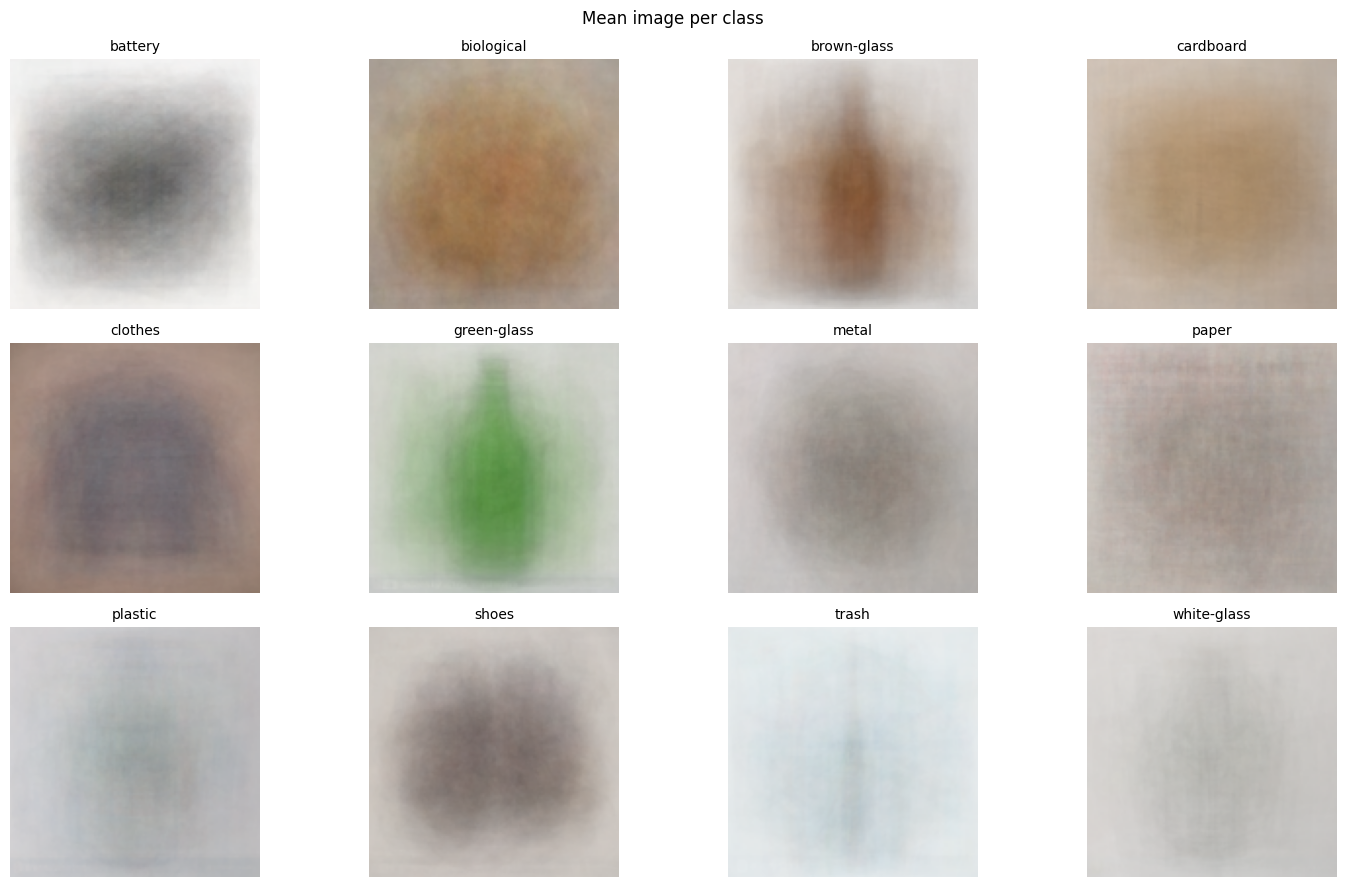

In [16]:
TARGET_SIZE = (128, 128)
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    cls_paths = sampled[sampled["label"] == cls]["filepath"].tolist()
    acc = np.zeros((*TARGET_SIZE[::-1], 3), dtype=np.float64)
    n = 0
    for fp in cls_paths:
        img = Image.open(fp).convert("RGB").resize(TARGET_SIZE)
        acc += np.asarray(img, dtype=np.float64)
        n += 1
    mean_img = (acc / n).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")

plt.suptitle("Mean image per class")
plt.tight_layout()
plt.show()


**Reading the mean images:** classes are taken on a common studio background (e.g. cardboard),
(wood, metal, glass) tend to be more rectangular in shape.Classes with the materials (paper, plastic) are more blob-like in the mean image, while those with the materials (wood, metal, glass) tend to be more rectangular.
scraped web photos with different background colors (clothes, biological) have an average of gray color.
Supporting finding 1 above: Background inconsistencies among sources.


## Summary of cleaning decisions carried into modeling

Exact duplicate files, zero-byte and corrupt files (as counted in Section 4) will be dropped.
With one copy per hash (also counted in Section 4). All images will be resized to 224×224 and will be forced.
To 3 channels (RGB). The data will be randomly split 70/15/15 train/val/test and computed.
after de-duplication. To offset this imbalance (as revealed in Section 5), class-weighted loss will be used,
Heavy augmentation (crop, color jitter and background variations) will be used to overcome the
An analysis of the domain shift of the studio-vs-web domain was performed in Section 7.